# Draw both agents

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DPI = 900


EXCEL_PATH = "charades_traj_summary.xlsx"
SHEET_NAME = "all_summary"

# -----------------------------------------------------------------------
# DATA LOADING
# -----------------------------------------------------------------------
def load_all_summary(path=EXCEL_PATH, sheet=SHEET_NAME):
    df = pd.read_excel(path, sheet_name=sheet)
    df = df.dropna(subset=['id'])
    return df   # <-- was commented out, which made this return None


def parse_coord_string(s):
    """Parses x1/y1/x2/y2 cell values. Handles both:
       "[2350.0, 2345.62, ...]"            (plain numbers)
       "['2350.0', '2345.62', ...]"        (quoted numbers, as in all_summary)
    """
    if isinstance(s, (list, np.ndarray)):
        return np.array(s, dtype=float)
    if isinstance(s, str):
        s = s.strip("[]").replace("'", "")
        return np.array([float(v.strip()) for v in s.split(',') if v.strip()])
    raise ValueError("Unsupported type for coordinate parsing")


def _downsample_keep_last(arr, step):
    """Take every `step`-th frame, always keeping the final frame so the
    trajectory's true endpoint doesn't shift."""
    idx = list(range(0, len(arr), step))
    if idx[-1] != len(arr) - 1:
        idx.append(len(arr) - 1)
    return arr[idx]


def get_trajectory_by_id(df, video_id, downsample=1):
    row = df.loc[df['id'] == video_id]
    if row.empty:
        raise ValueError(f"No row found for id={video_id}")
    row = row.iloc[0]

    x1 = parse_coord_string(row.x1)
    y1 = parse_coord_string(row.y1)
    x2 = parse_coord_string(row.x2)
    y2 = parse_coord_string(row.y2)
    label = row.label

    if downsample > 1:
        x1 = _downsample_keep_last(x1, downsample)
        y1 = _downsample_keep_last(y1, downsample)
        x2 = _downsample_keep_last(x2, downsample)
        y2 = _downsample_keep_last(y2, downsample)

    return x1, y1, x2, y2, label


# -----------------------------------------------------------------------
# PLOTTING — comet-trail style (constant color per agent, size + alpha
# grow over time, faint connecting line underneath)
# -----------------------------------------------------------------------
def plot_faded_traj(ax, x, y, base_color=(0.9, 0.2, 0.2),
                     min_size=5, max_size=30,
                     min_alpha=0.05, max_alpha=1.0,
                     line_alpha=0.3, line_width=1.0):
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)
    t = np.linspace(0, 1, n)

    sizes_area = (min_size + (max_size - min_size) * t) ** 2
    alphas = min_alpha + (max_alpha - min_alpha) * t

    r, g, b = base_color
    colors = np.zeros((n, 4))
    colors[:, 0], colors[:, 1], colors[:, 2], colors[:, 3] = r, g, b, alphas

    ax.scatter(x, y, s=sizes_area, c=colors, edgecolors='none', zorder=2)
    ax.plot(x, y, color=base_color, alpha=line_alpha, linewidth=line_width,
            zorder=1)


def plot_trajectory_pair(x1, y1, x2, y2,
                          color_a=(0.86, 0.08, 0.23),   # red
                          color_b=(0.26, 0.31, 0.69),   # blue
                          figsize=(8, 6), dpi=DPI,     # 4:3 ratio canvas
                          save_path=None, title=None,
                          margin=0.2,
                          canvas_width=None, canvas_height=None,
                          flip_y=False):
    """
    If canvas_width/canvas_height are given, every plot uses the SAME
    fixed axis limits (0..canvas_width, 0..canvas_height) instead of
    auto-fitting to each trajectory's own data range. This makes
    different trajectories directly comparable in scale -- two plots
    with the same physical distance will look the same size, instead of
    each being independently zoomed to fill the panel.

    flip_y=True flips the y-axis (origin top-left, like image/video
    coordinates) -- set this if your data uses that convention.
    """
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    if flip_y and canvas_height is not None:
        y1 = canvas_height - y1
        y2 = canvas_height - y2

    plot_faded_traj(ax, x1, y1, base_color=color_a)
    plot_faded_traj(ax, x2, y2, base_color=color_b)

    if canvas_width is not None and canvas_height is not None:
        # FIXED canvas: same bounds for every plot, so scale is comparable
        # across different trajectories/panels.
        ax.set_xlim(0, canvas_width)
        ax.set_ylim(0, canvas_height)
        ax.set_aspect('equal', adjustable='box')
    else:
        # fallback: auto-fit to this trajectory's own data (old behavior)
        ax.margins(margin)
        ax.set_aspect('equal', adjustable='datalim')

    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=14)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()
    plt.close(fig)


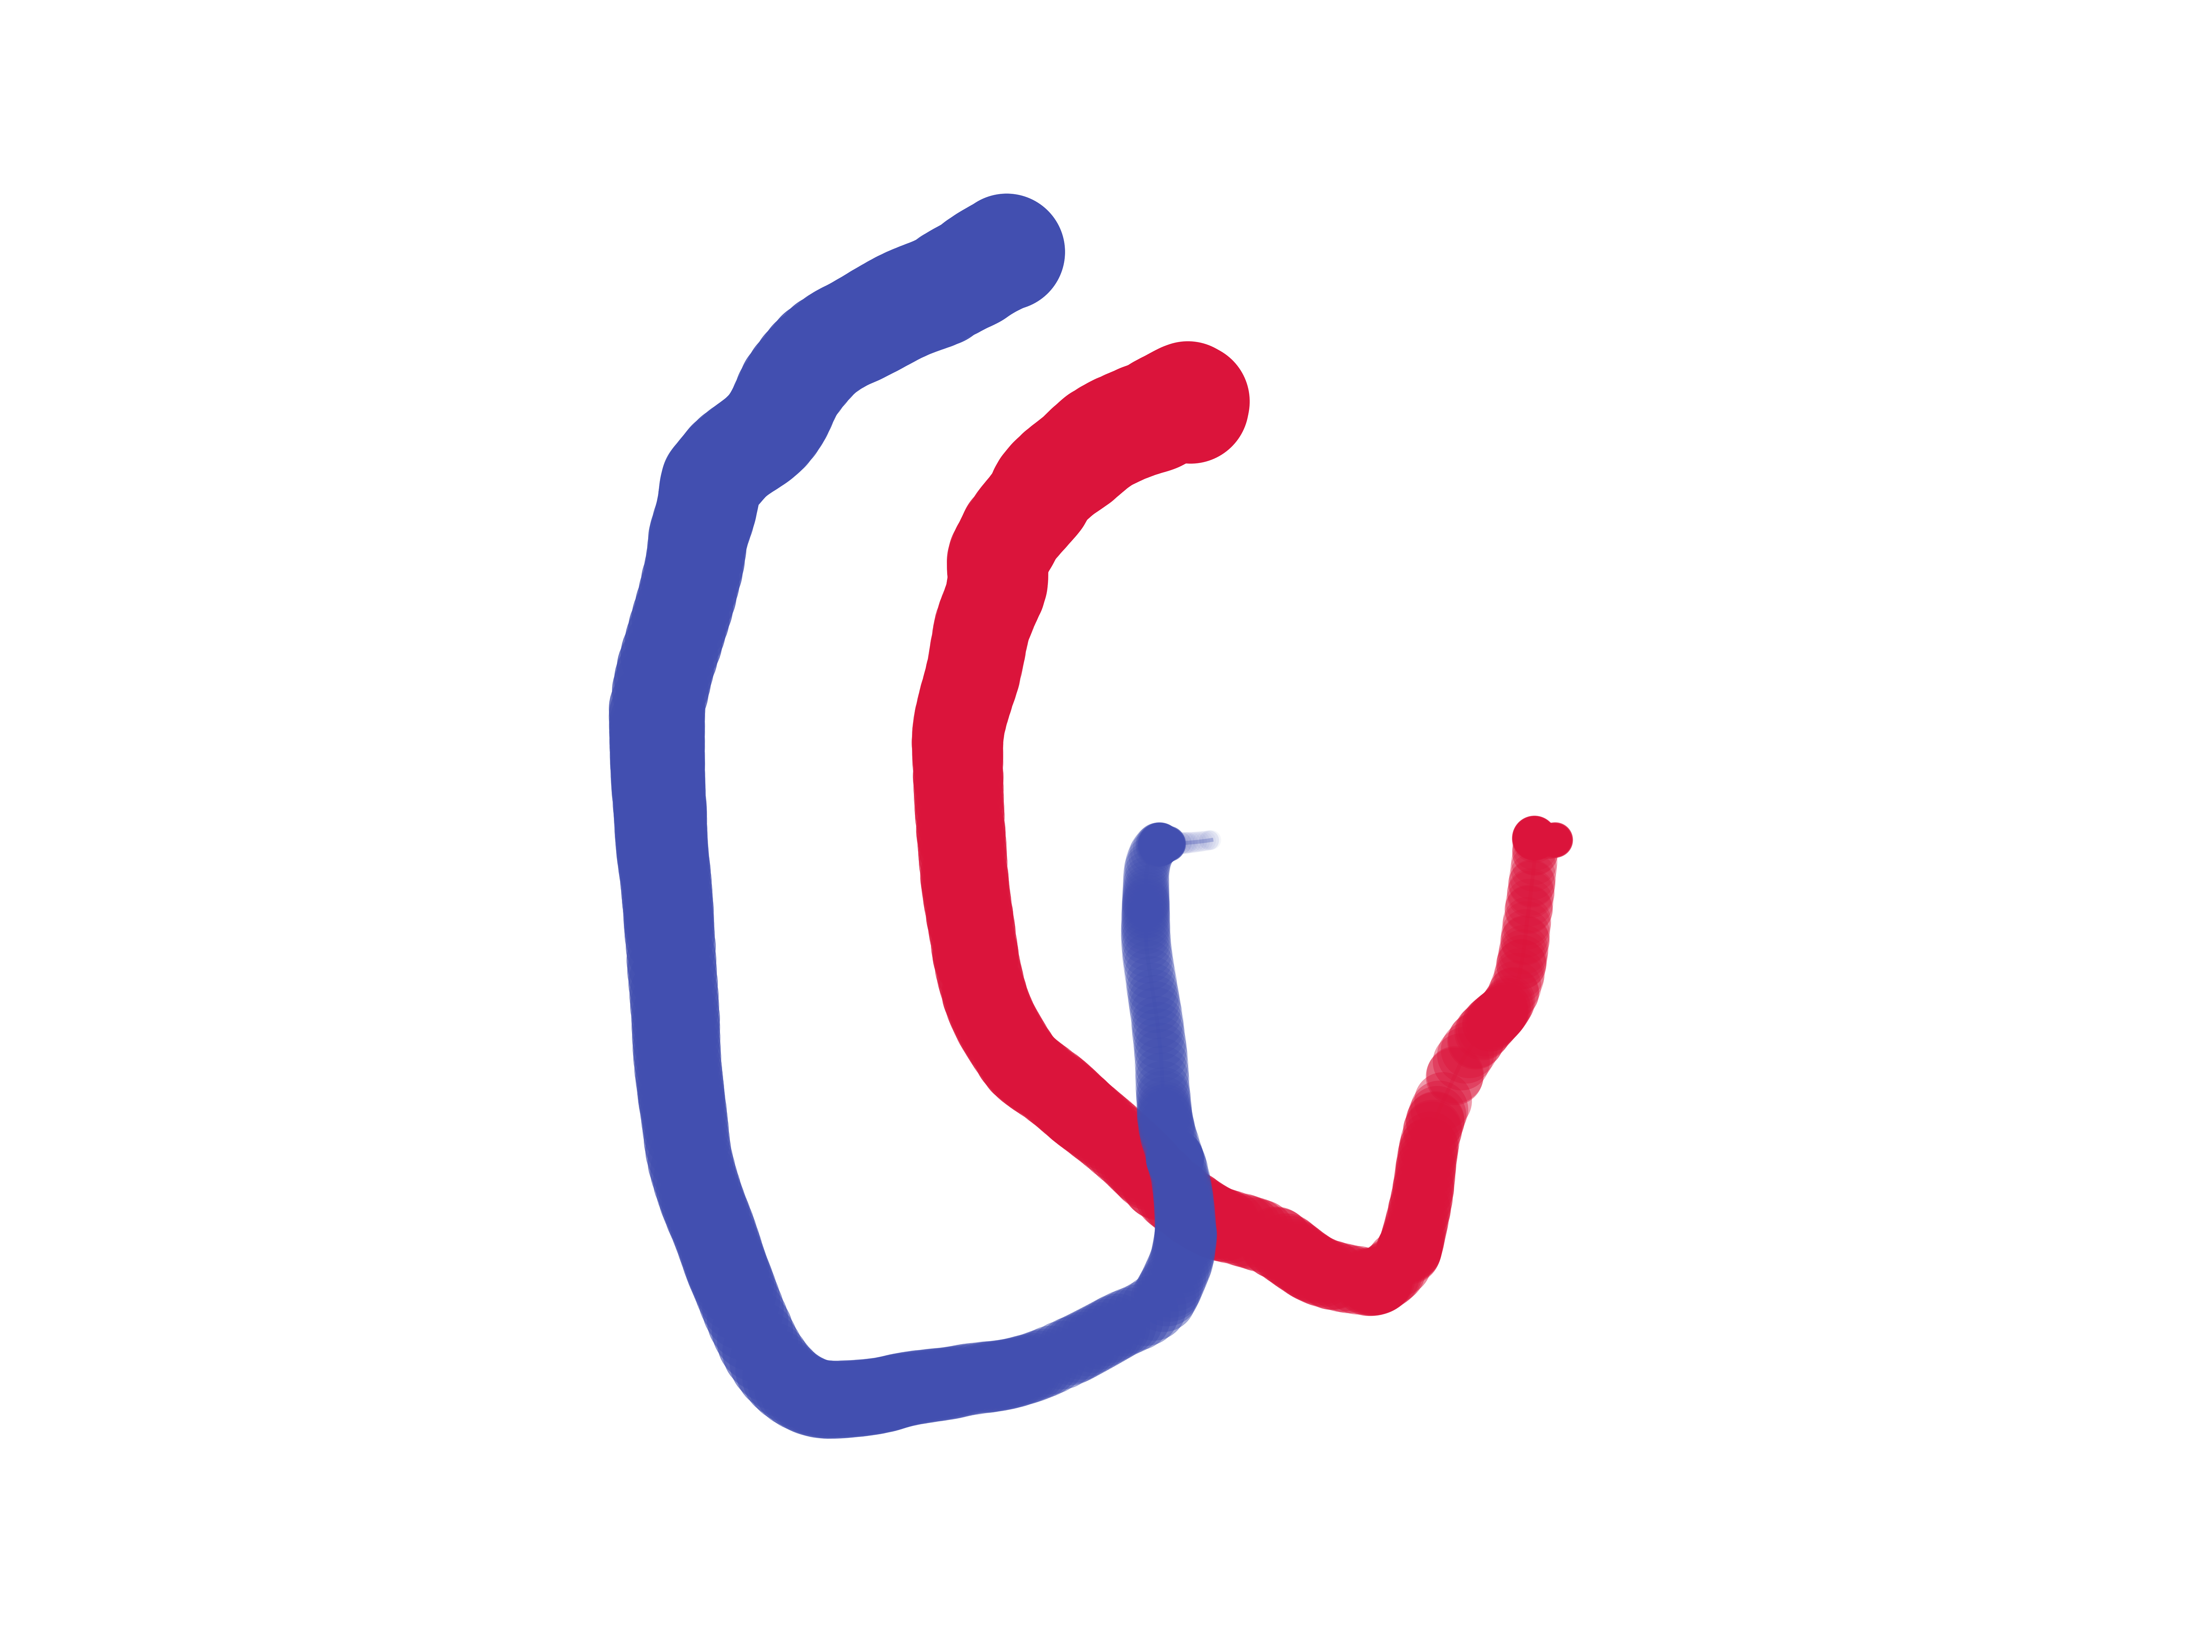

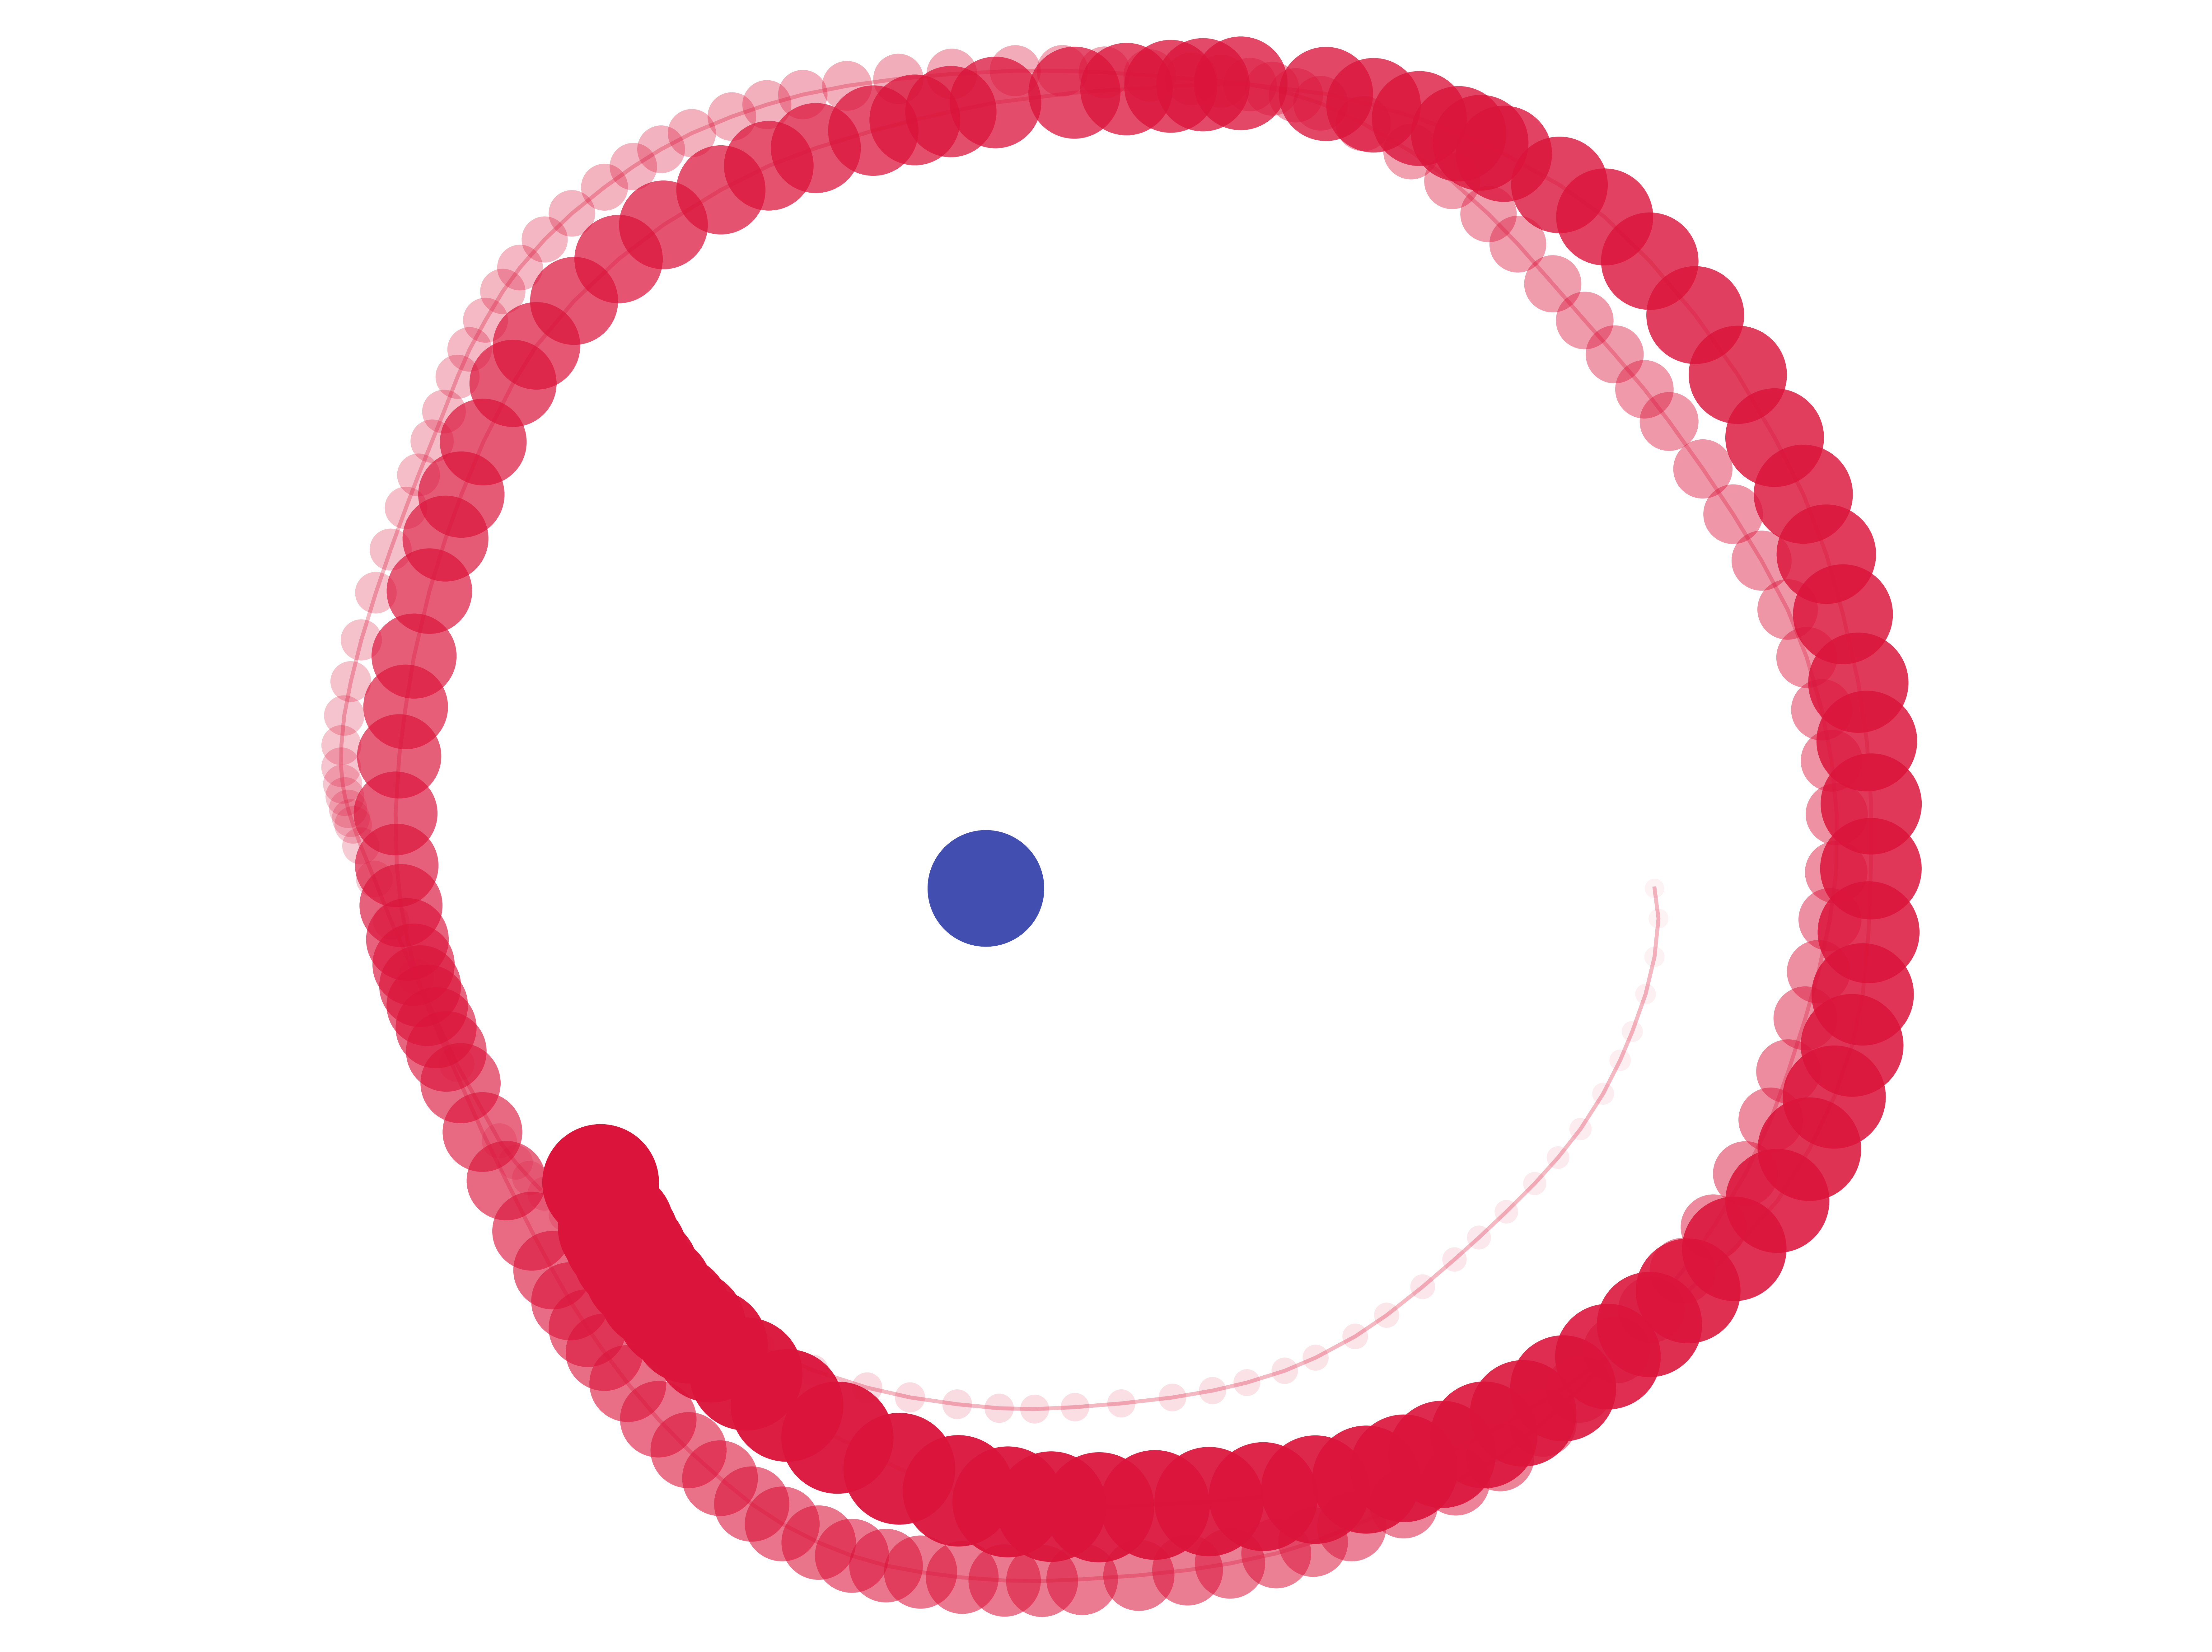

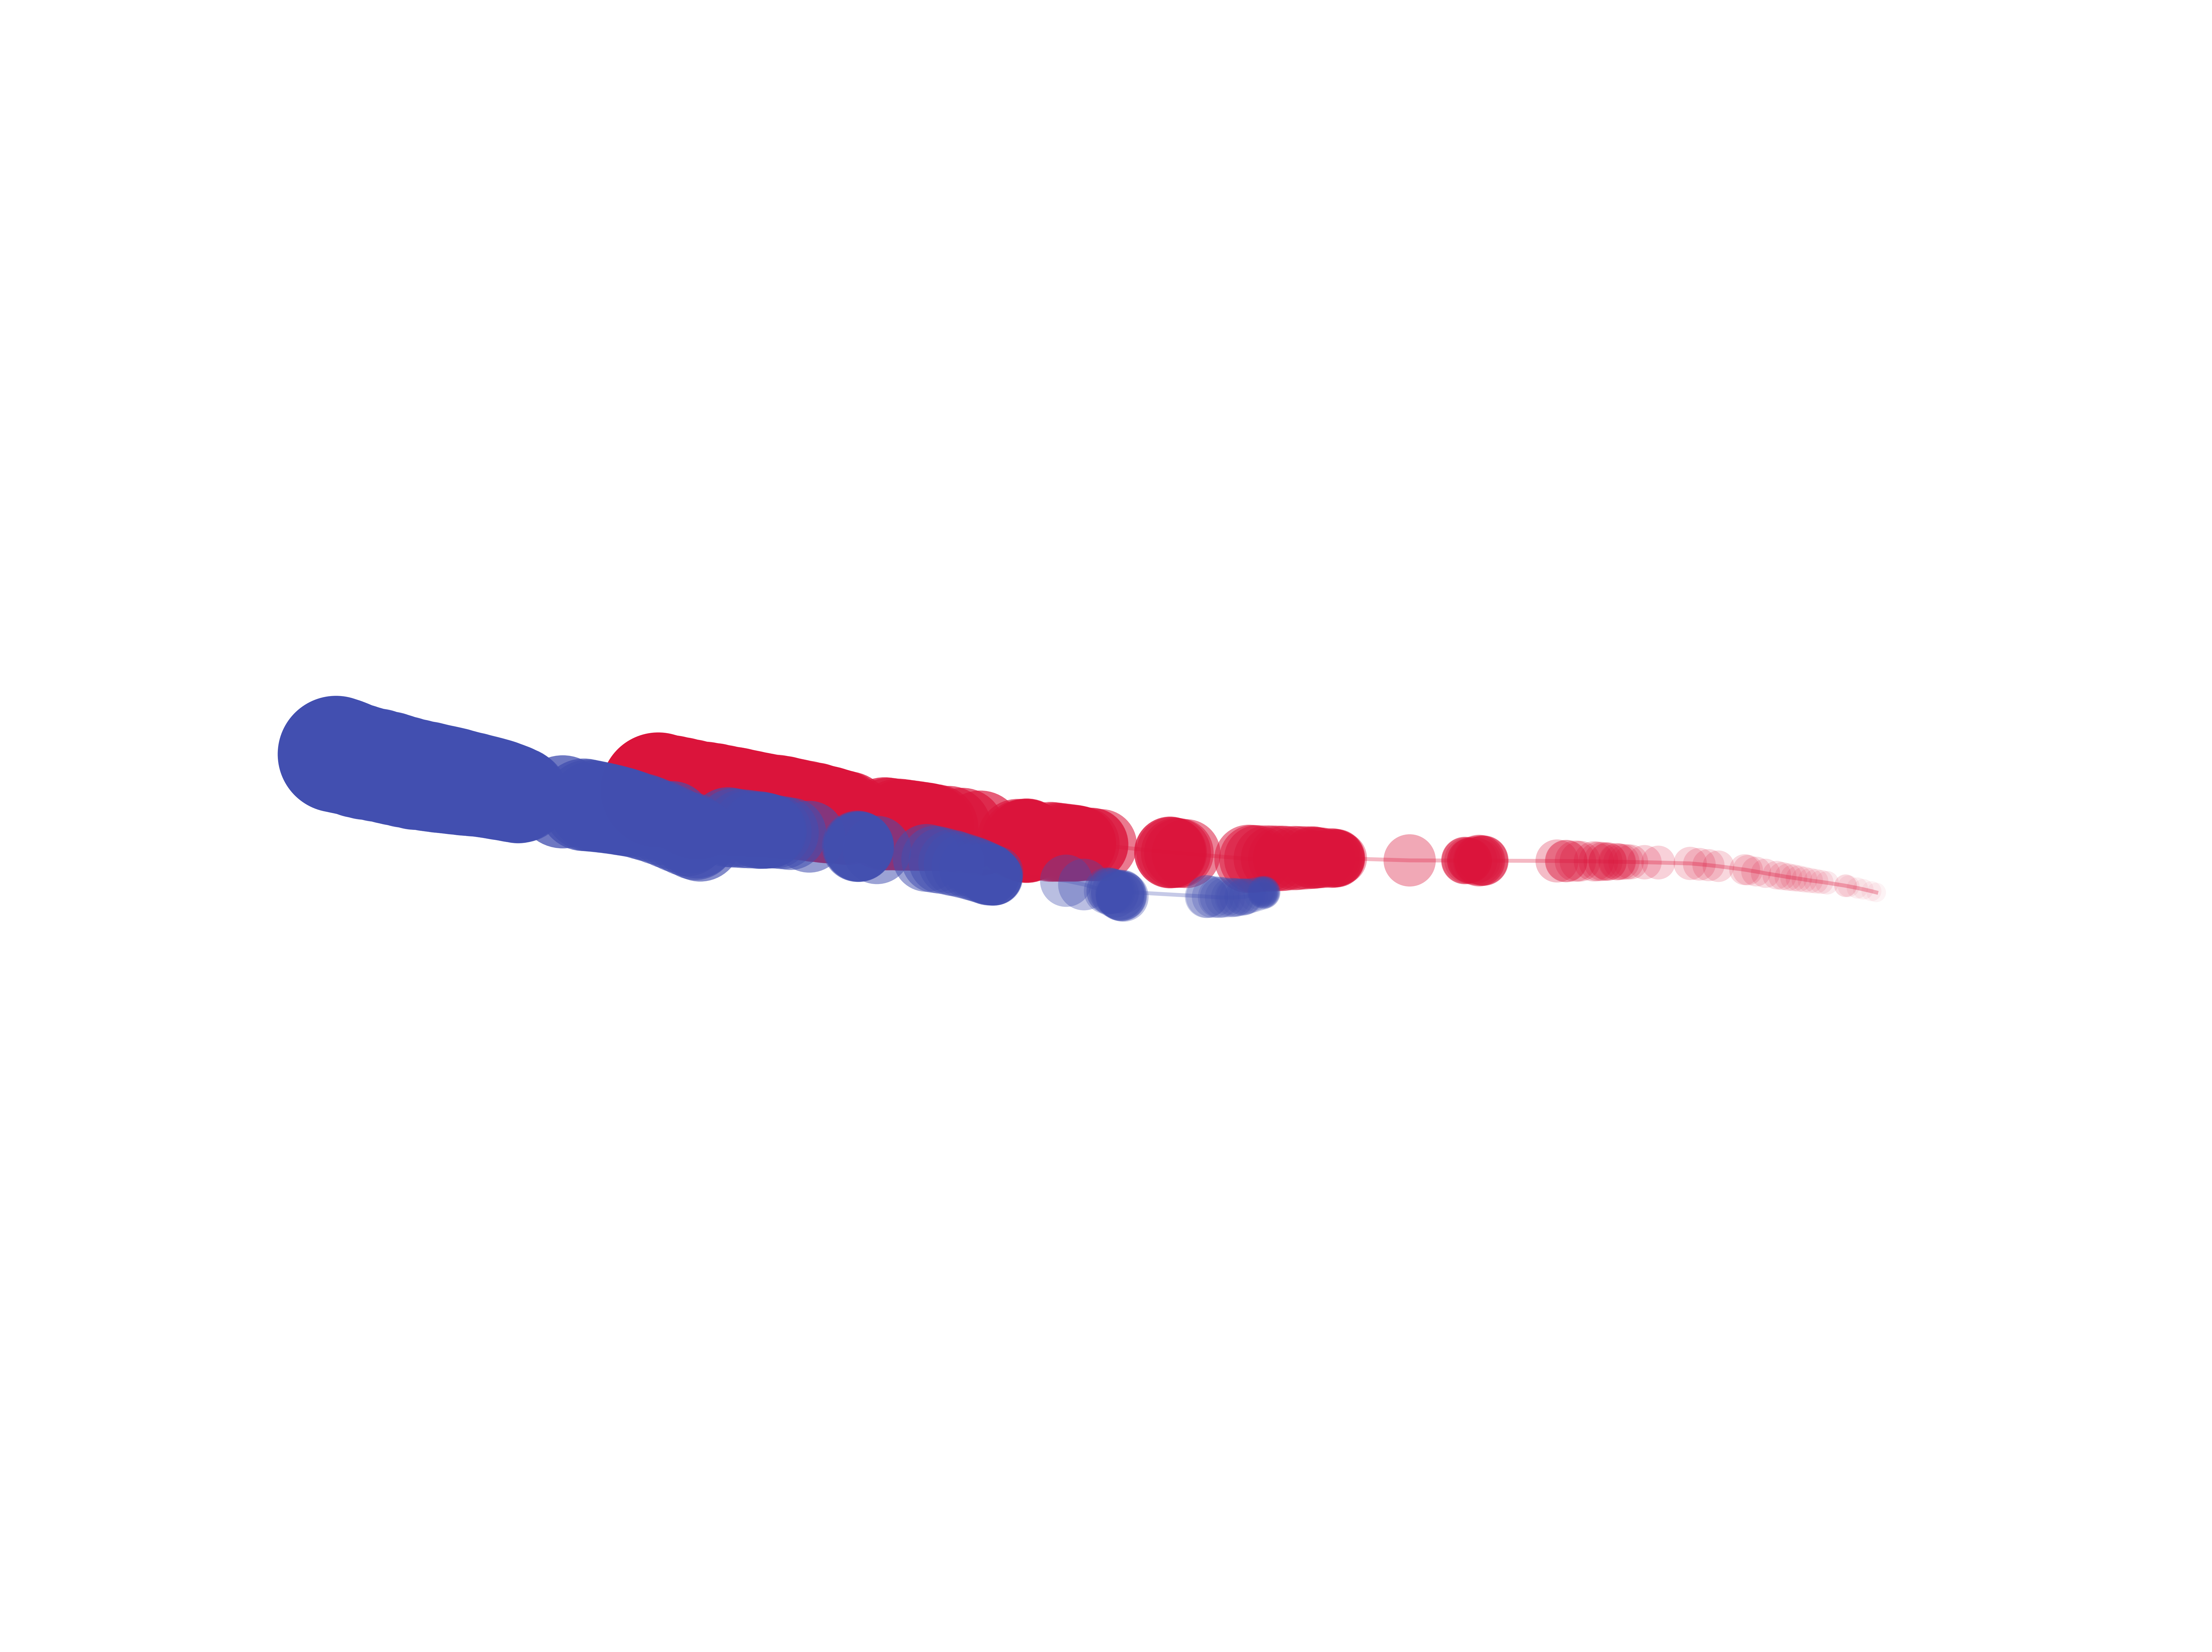

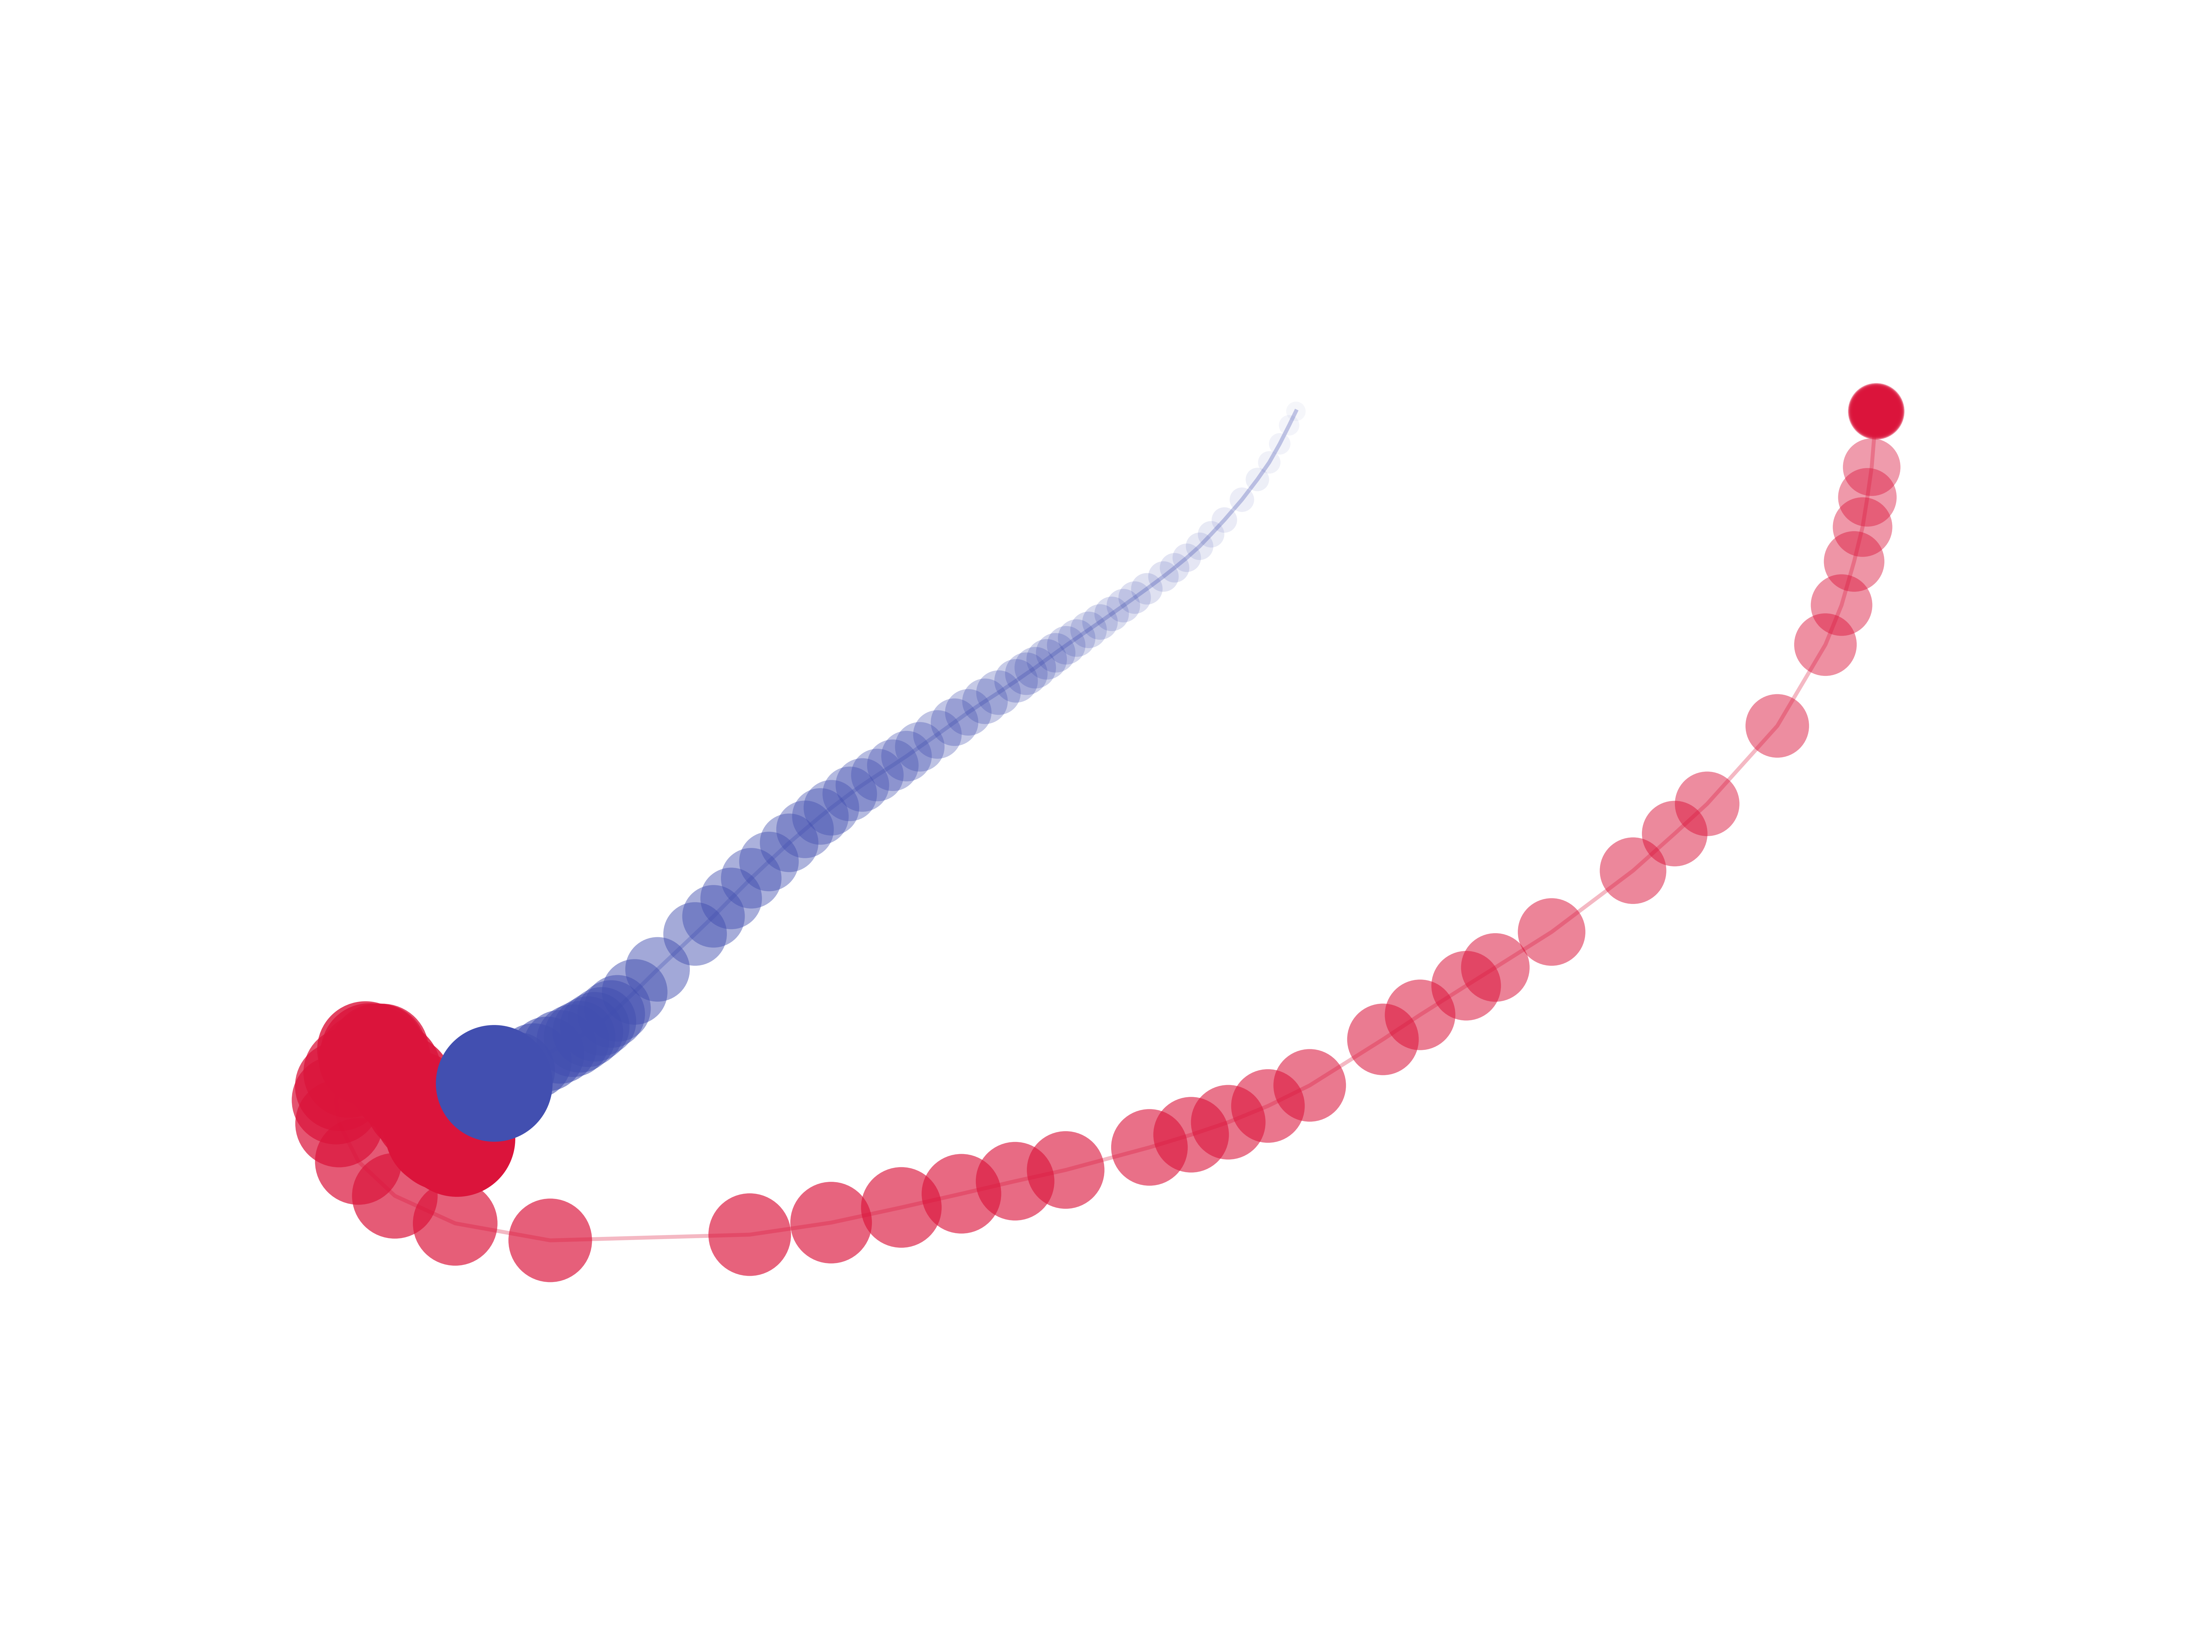

In [ ]:
# Draw both agents
df = load_all_summary()

video_ids = [6300, 6017, 5568, 4788]
for video_id in video_ids:
    x1, y1, x2, y2, label = get_trajectory_by_id(df, video_id, downsample=1)

    plot_trajectory_pair(
        x1, y1, x2, y2,
        save_path=f"./traj_{video_id}.svg"
    )

# Draw force generated trajectory, and agent only

In [ ]:
DPI = 900

EXCEL_PATH = "charades_summary_generated_force_ver3.xlsx"
SHEET_NAME = "summary"

# -----------------------------------------------------------------------
# DATA LOADING
# -----------------------------------------------------------------------
def load_force_traj_summary(path=EXCEL_PATH, sheet=SHEET_NAME):
    df = pd.read_excel(path, sheet_name=sheet)
    df = df.dropna(subset=['force_a_id', 'traj_b_id'])
    return df


def parse_coord_string(s):
    if isinstance(s, (list, np.ndarray)):
        return np.array(s, dtype=float)
    if isinstance(s, str):
        s = s.strip("[]").replace("'", "")
        return np.array([float(v.strip()) for v in s.split(',') if v.strip()])
    raise ValueError("Unsupported type for coordinate parsing")


def _downsample_keep_last(arr, step):
    idx = list(range(0, len(arr), step))
    if idx[-1] != len(arr) - 1:
        idx.append(len(arr) - 1)
    return arr[idx]


def get_trajectory_by_force_traj(df, force_id, traj_id, downsample=1):
    """
    A row here is uniquely identified by the PAIR (force_a_id, traj_b_id),
    not a single id -- one force agent can be paired with many trajectory
    agents and vice versa.

    Returns:
      x_force, y_force   -> the force agent's path  (x1/y1, force_a_label)
      x_traj,  y_traj    -> the trajectory agent's path (x2/y2, traj_b_label)
      force_label, traj_label
    """
    row = df.loc[(df['force_a_id'] == force_id) & (df['traj_b_id'] == traj_id)]
    if row.empty:
        raise ValueError(
            f"No row found for force_a_id={force_id}, traj_b_id={traj_id}"
        )
    row = row.iloc[0]

    x_force = parse_coord_string(row.x1)
    y_force = parse_coord_string(row.y1)
    x_traj = parse_coord_string(row.x2)
    y_traj = parse_coord_string(row.y2)

    if downsample > 1:
        x_force = _downsample_keep_last(x_force, downsample)
        y_force = _downsample_keep_last(y_force, downsample)
        x_traj = _downsample_keep_last(x_traj, downsample)
        y_traj = _downsample_keep_last(y_traj, downsample)

    return x_force, y_force, x_traj, y_traj, row.force_a_label, row.traj_b_label


# -----------------------------------------------------------------------
# PLOTTING — comet-trail, with EXPLICIT per-agent-role color control
# -----------------------------------------------------------------------
def plot_faded_traj(ax, x, y, base_color,
                     min_size=5, max_size=30,
                     min_alpha=0.05, max_alpha=1.0,
                     line_alpha=0.3, line_width=1.0,
                     line_fades=False):
    """
    base_color: (r, g, b) or (r, g, b, opacity_scale).
    If a 4th value is given, it multiplies the whole fade gradient --
    e.g. (0.26, 0.31, 0.69, 0.3) makes that entire trajectory 30%
    opacity at most, useful for de-emphasizing/ghosting one agent
    while the other stays fully visible.

    line_fades=True makes the connecting line fade alongside the dots
    (via LineCollection, since a plain Line2D can't take an alpha array).
    line_fades=False (default) draws a flat low-alpha line, as before.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)
    t = np.linspace(0, 1, n)

    sizes_area = (min_size + (max_size - min_size) * t) ** 2
    alphas = min_alpha + (max_alpha - min_alpha) * t

    if len(base_color) == 4:
        r, g, b, opacity_scale = base_color
    else:
        r, g, b = base_color
        opacity_scale = 1.0
    alphas = alphas * opacity_scale

    colors = np.zeros((n, 4))
    colors[:, 0], colors[:, 1], colors[:, 2], colors[:, 3] = r, g, b, alphas

    ax.scatter(x, y, s=sizes_area, c=colors, edgecolors='none', zorder=2)

    if line_fades:
        # per-segment alpha -> needs LineCollection, Line2D can't do this
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        seg_colors = np.zeros((n - 1, 4))
        seg_colors[:, 0], seg_colors[:, 1], seg_colors[:, 2] = r, g, b
        seg_colors[:, 3] = alphas[:-1]
        lc = LineCollection(segments, colors=seg_colors, linewidths=line_width,
                             zorder=1)
        ax.add_collection(lc)
    else:
        ax.plot(x, y, color=(r, g, b), alpha=line_alpha * opacity_scale,
                linewidth=line_width, zorder=1)


def plot_force_traj_pair(x_force, y_force, x_traj, y_traj,
                          force_label=None, traj_label=None,
                          color_force=(0.86, 0.08, 0.23),   # red, default
                          color_traj=(0.26, 0.31, 0.69),    # blue, default
                          figsize=(6, 4.5), dpi=DPI,
                          save_path=None, title=None,
                          margin=0.2,
                          canvas_width=None, canvas_height=None,
                          flip_y=False,
                          line_fades=False):
    """
    color_force / color_traj let you independently control which color
    goes to the FORCE agent vs the TRAJECTORY agent -- e.g. you might
    always want the force agent in red regardless of which physical
    agent (A or B) it happens to be in the raw data.
    """
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    if flip_y and canvas_height is not None:
        y_force = canvas_height - y_force
        y_traj = canvas_height - y_traj

    plot_faded_traj(ax, x_force, y_force, base_color=color_force, line_fades=line_fades)
    plot_faded_traj(ax, x_traj, y_traj, base_color=color_traj, line_fades=line_fades)

    if canvas_width is not None and canvas_height is not None:
        ax.set_xlim(0, canvas_width)
        ax.set_ylim(0, canvas_height)
        ax.set_aspect('equal', adjustable='box')
    else:
        ax.margins(margin)
        ax.set_aspect('equal', adjustable='datalim')

    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=14)
    # elif force_label and traj_label:
    #     ax.set_title(f"force: {force_label}  |  traj: {traj_label}", fontsize=12)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig)

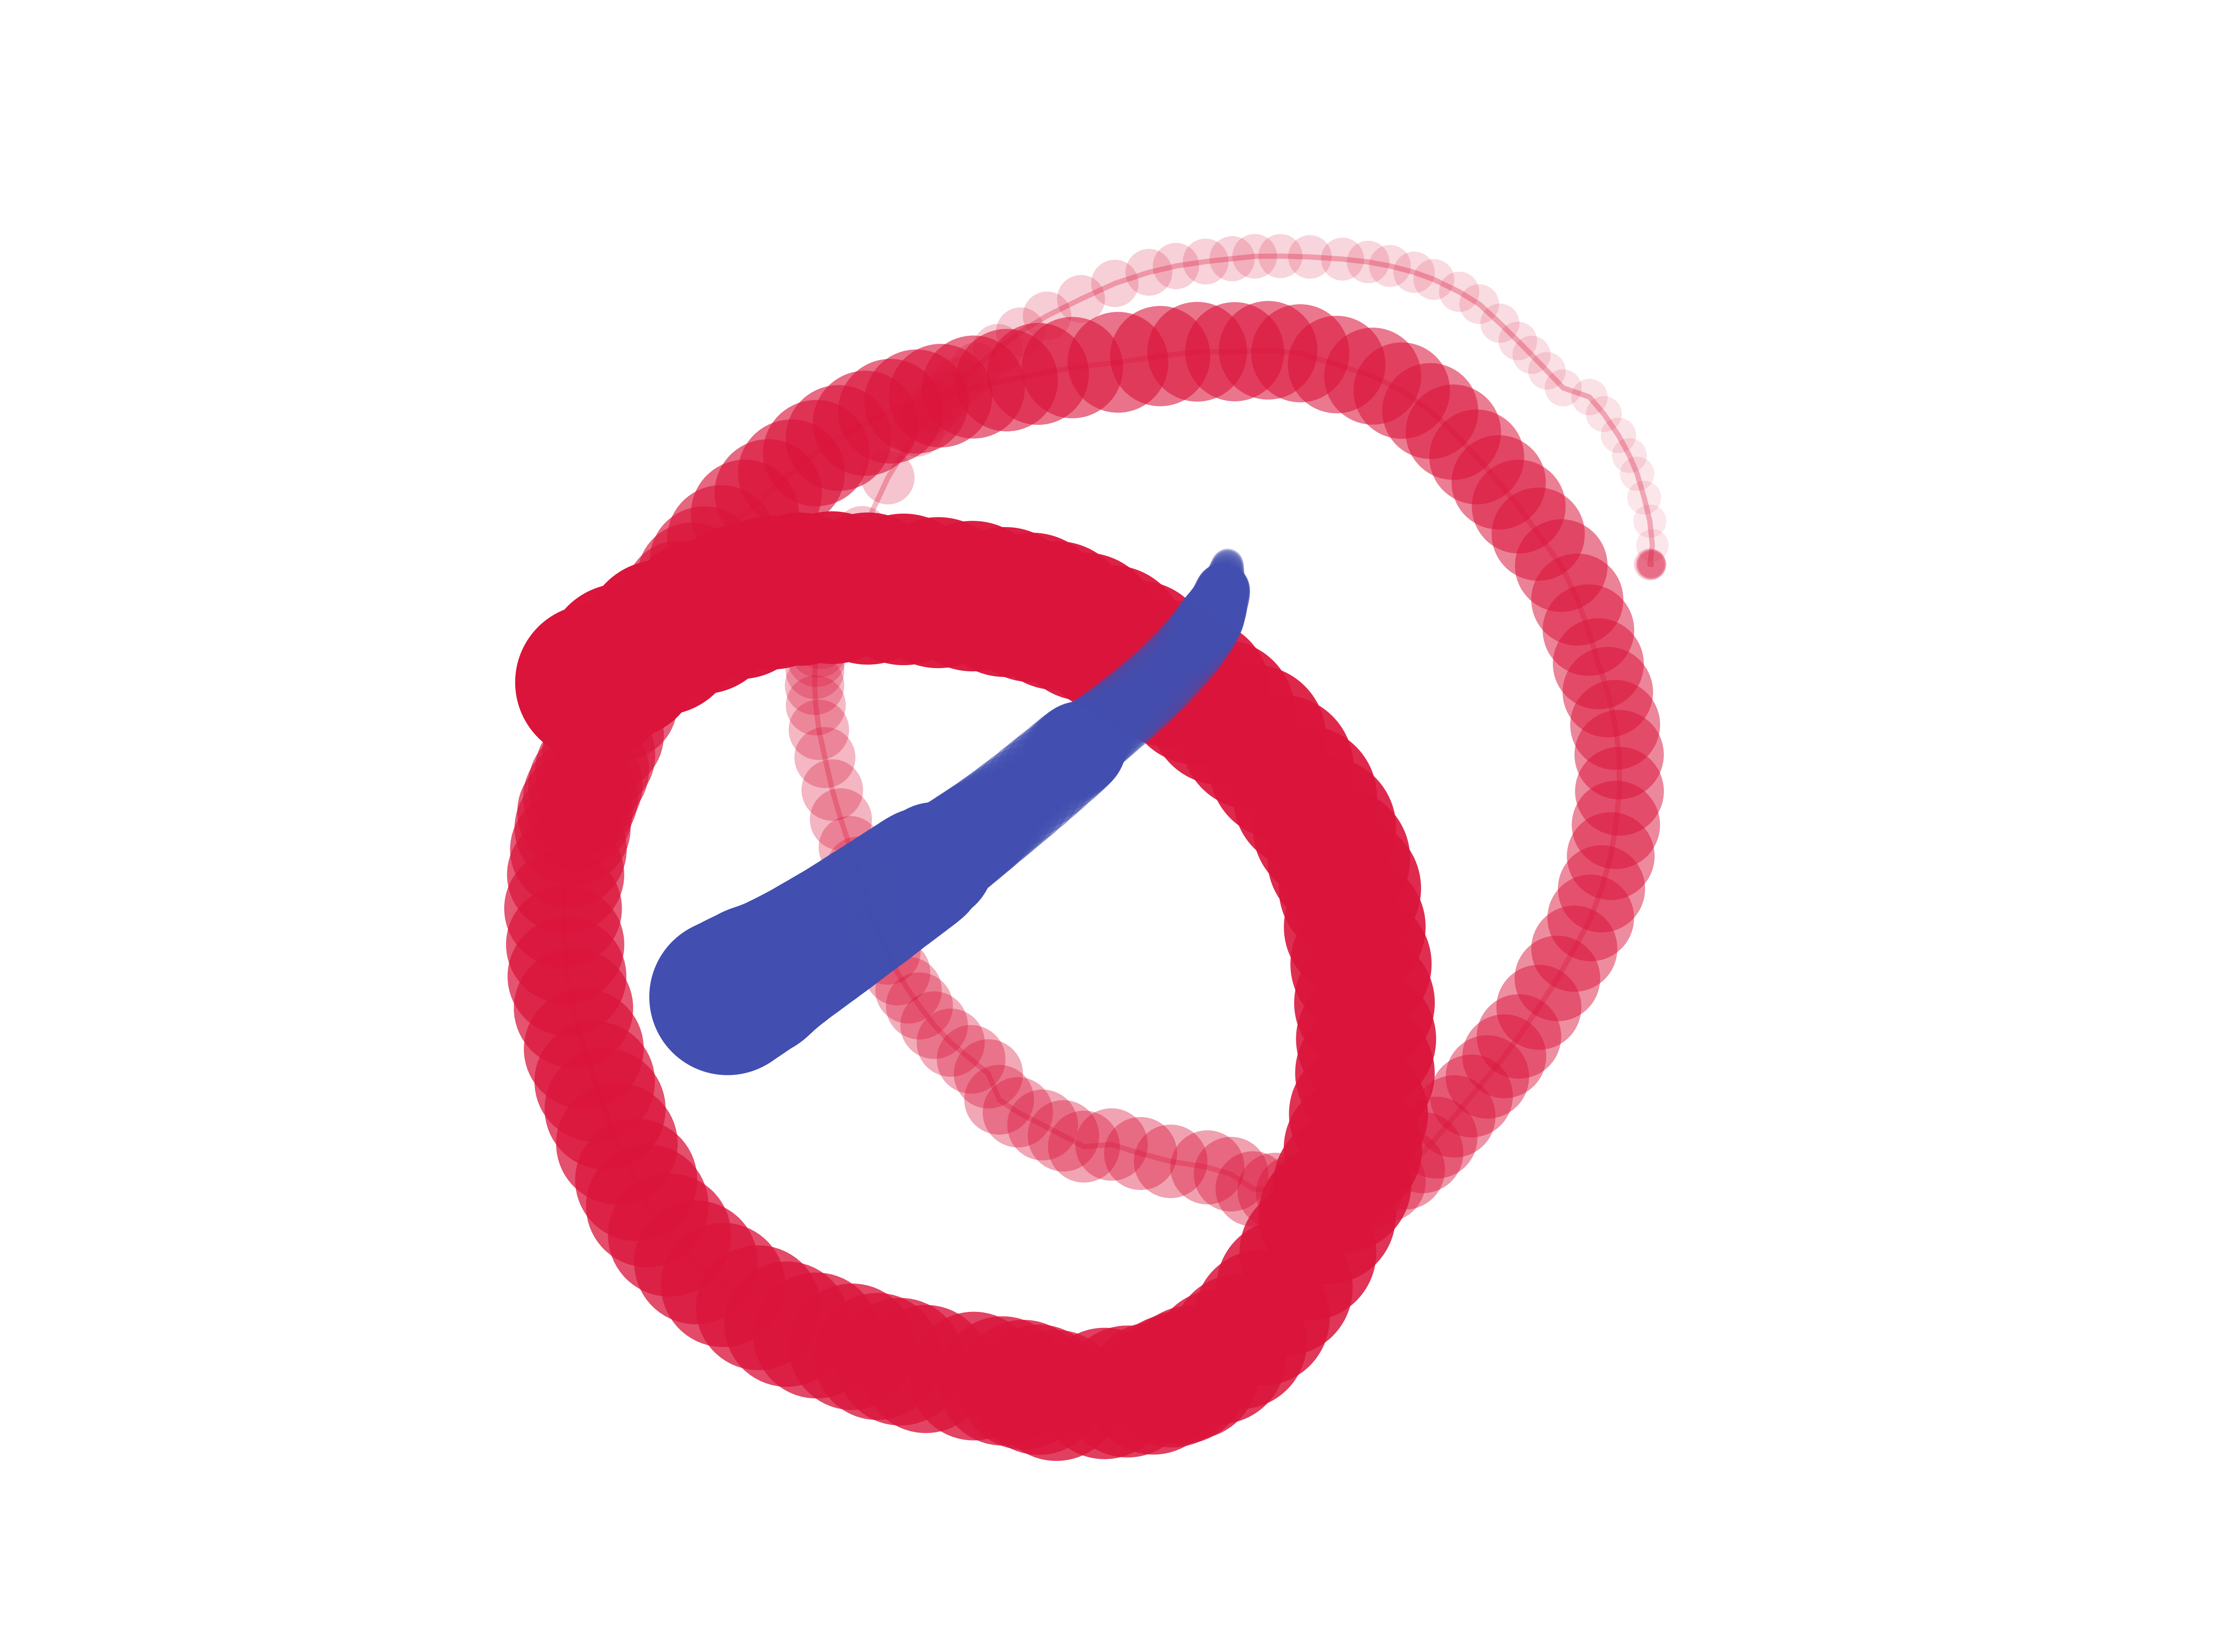

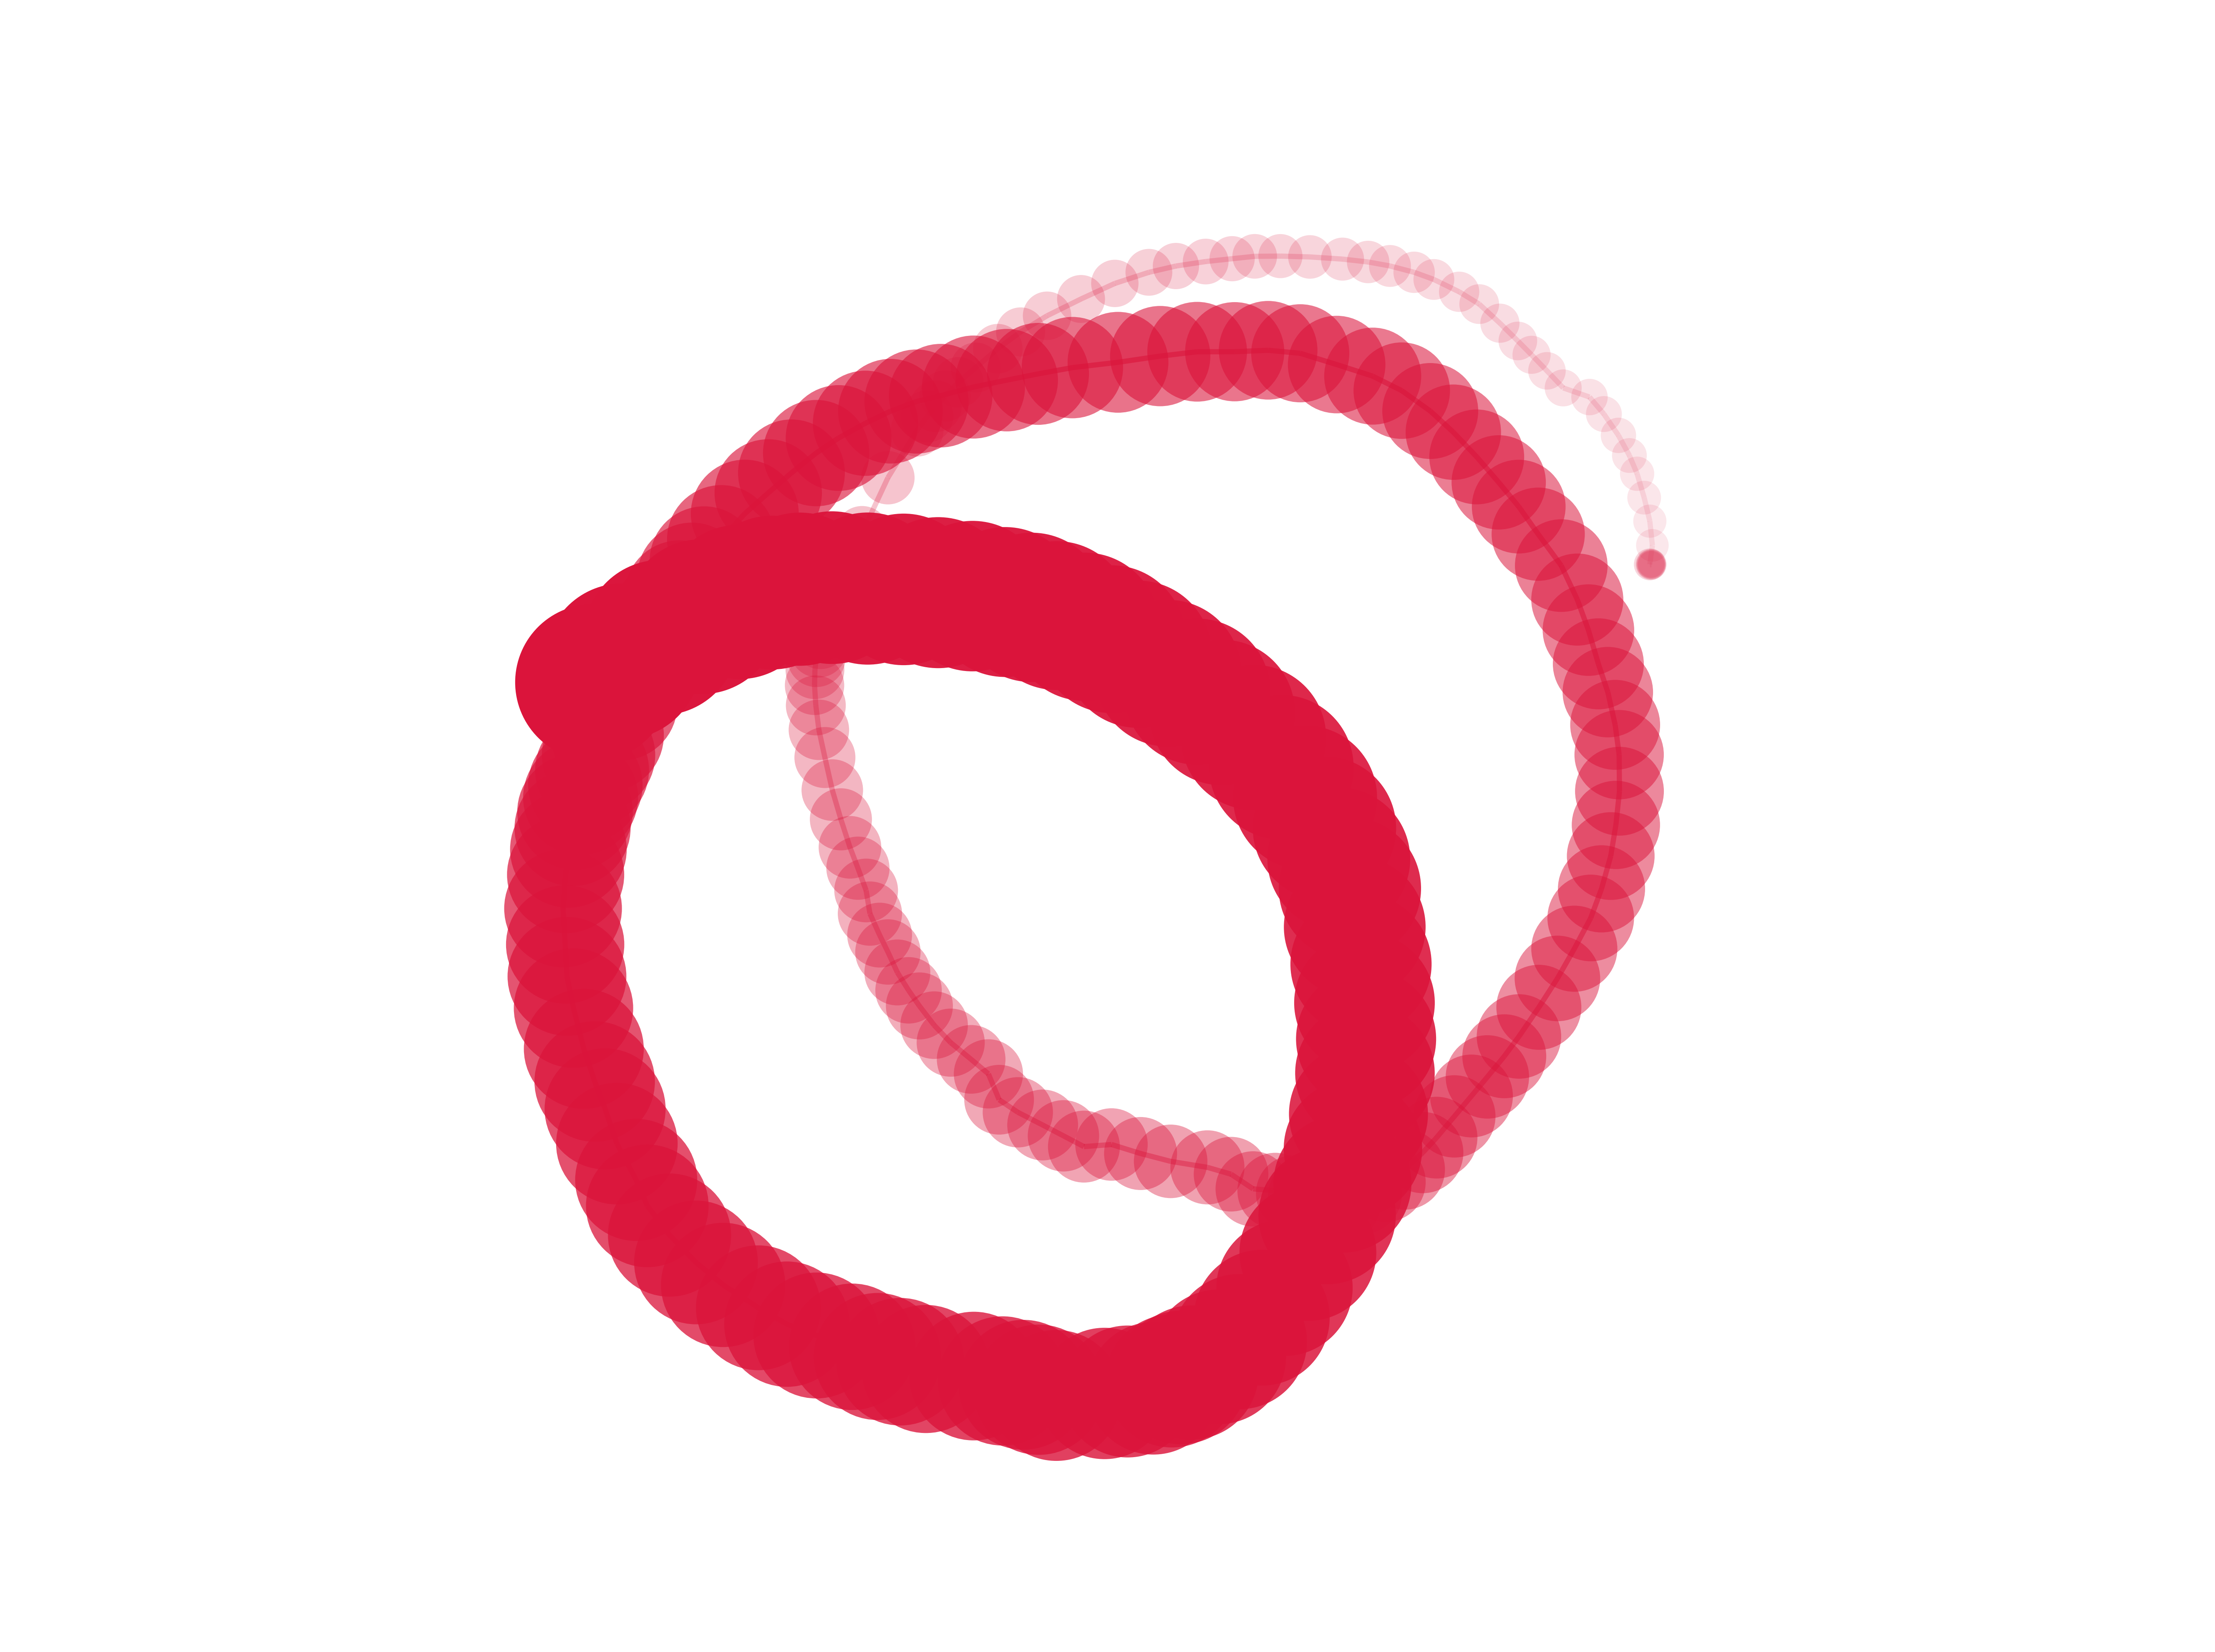

In [ ]:
df = load_force_traj_summary()

force_id = 6017   # force_a_id
traj_id = 1051    # traj_b_id

x_force, y_force, x_traj, y_traj, force_label, traj_label = \
    get_trajectory_by_force_traj(df, force_id, traj_id, downsample=1)

# example: force agent in red, trajectory agent in blue (default)
plot_force_traj_pair(
    x_force, y_force, x_traj, y_traj,
    force_label=force_label, traj_label=traj_label,
    save_path=f"./force{force_id}_traj{traj_id}_red-blue.svg"
)

# example: trajectory agent fully invisible (opacity_scale=0.0),
# force agent's connecting line also fades like its dots now
plot_force_traj_pair(
    x_force, y_force, x_traj, y_traj,
    force_label=force_label, traj_label=traj_label,
    color_force=(0.86, 0.08, 0.23),
    color_traj=(1.0, 1.0, 1.0, 0.0),   # fully transparent -> hidden
    line_fades=True,
    save_path=f"./force{force_id}_traj{traj_id}_red-hidden.svg"
)

# Draw both agents, but with the trajectory agent in grey and the force agent in blue

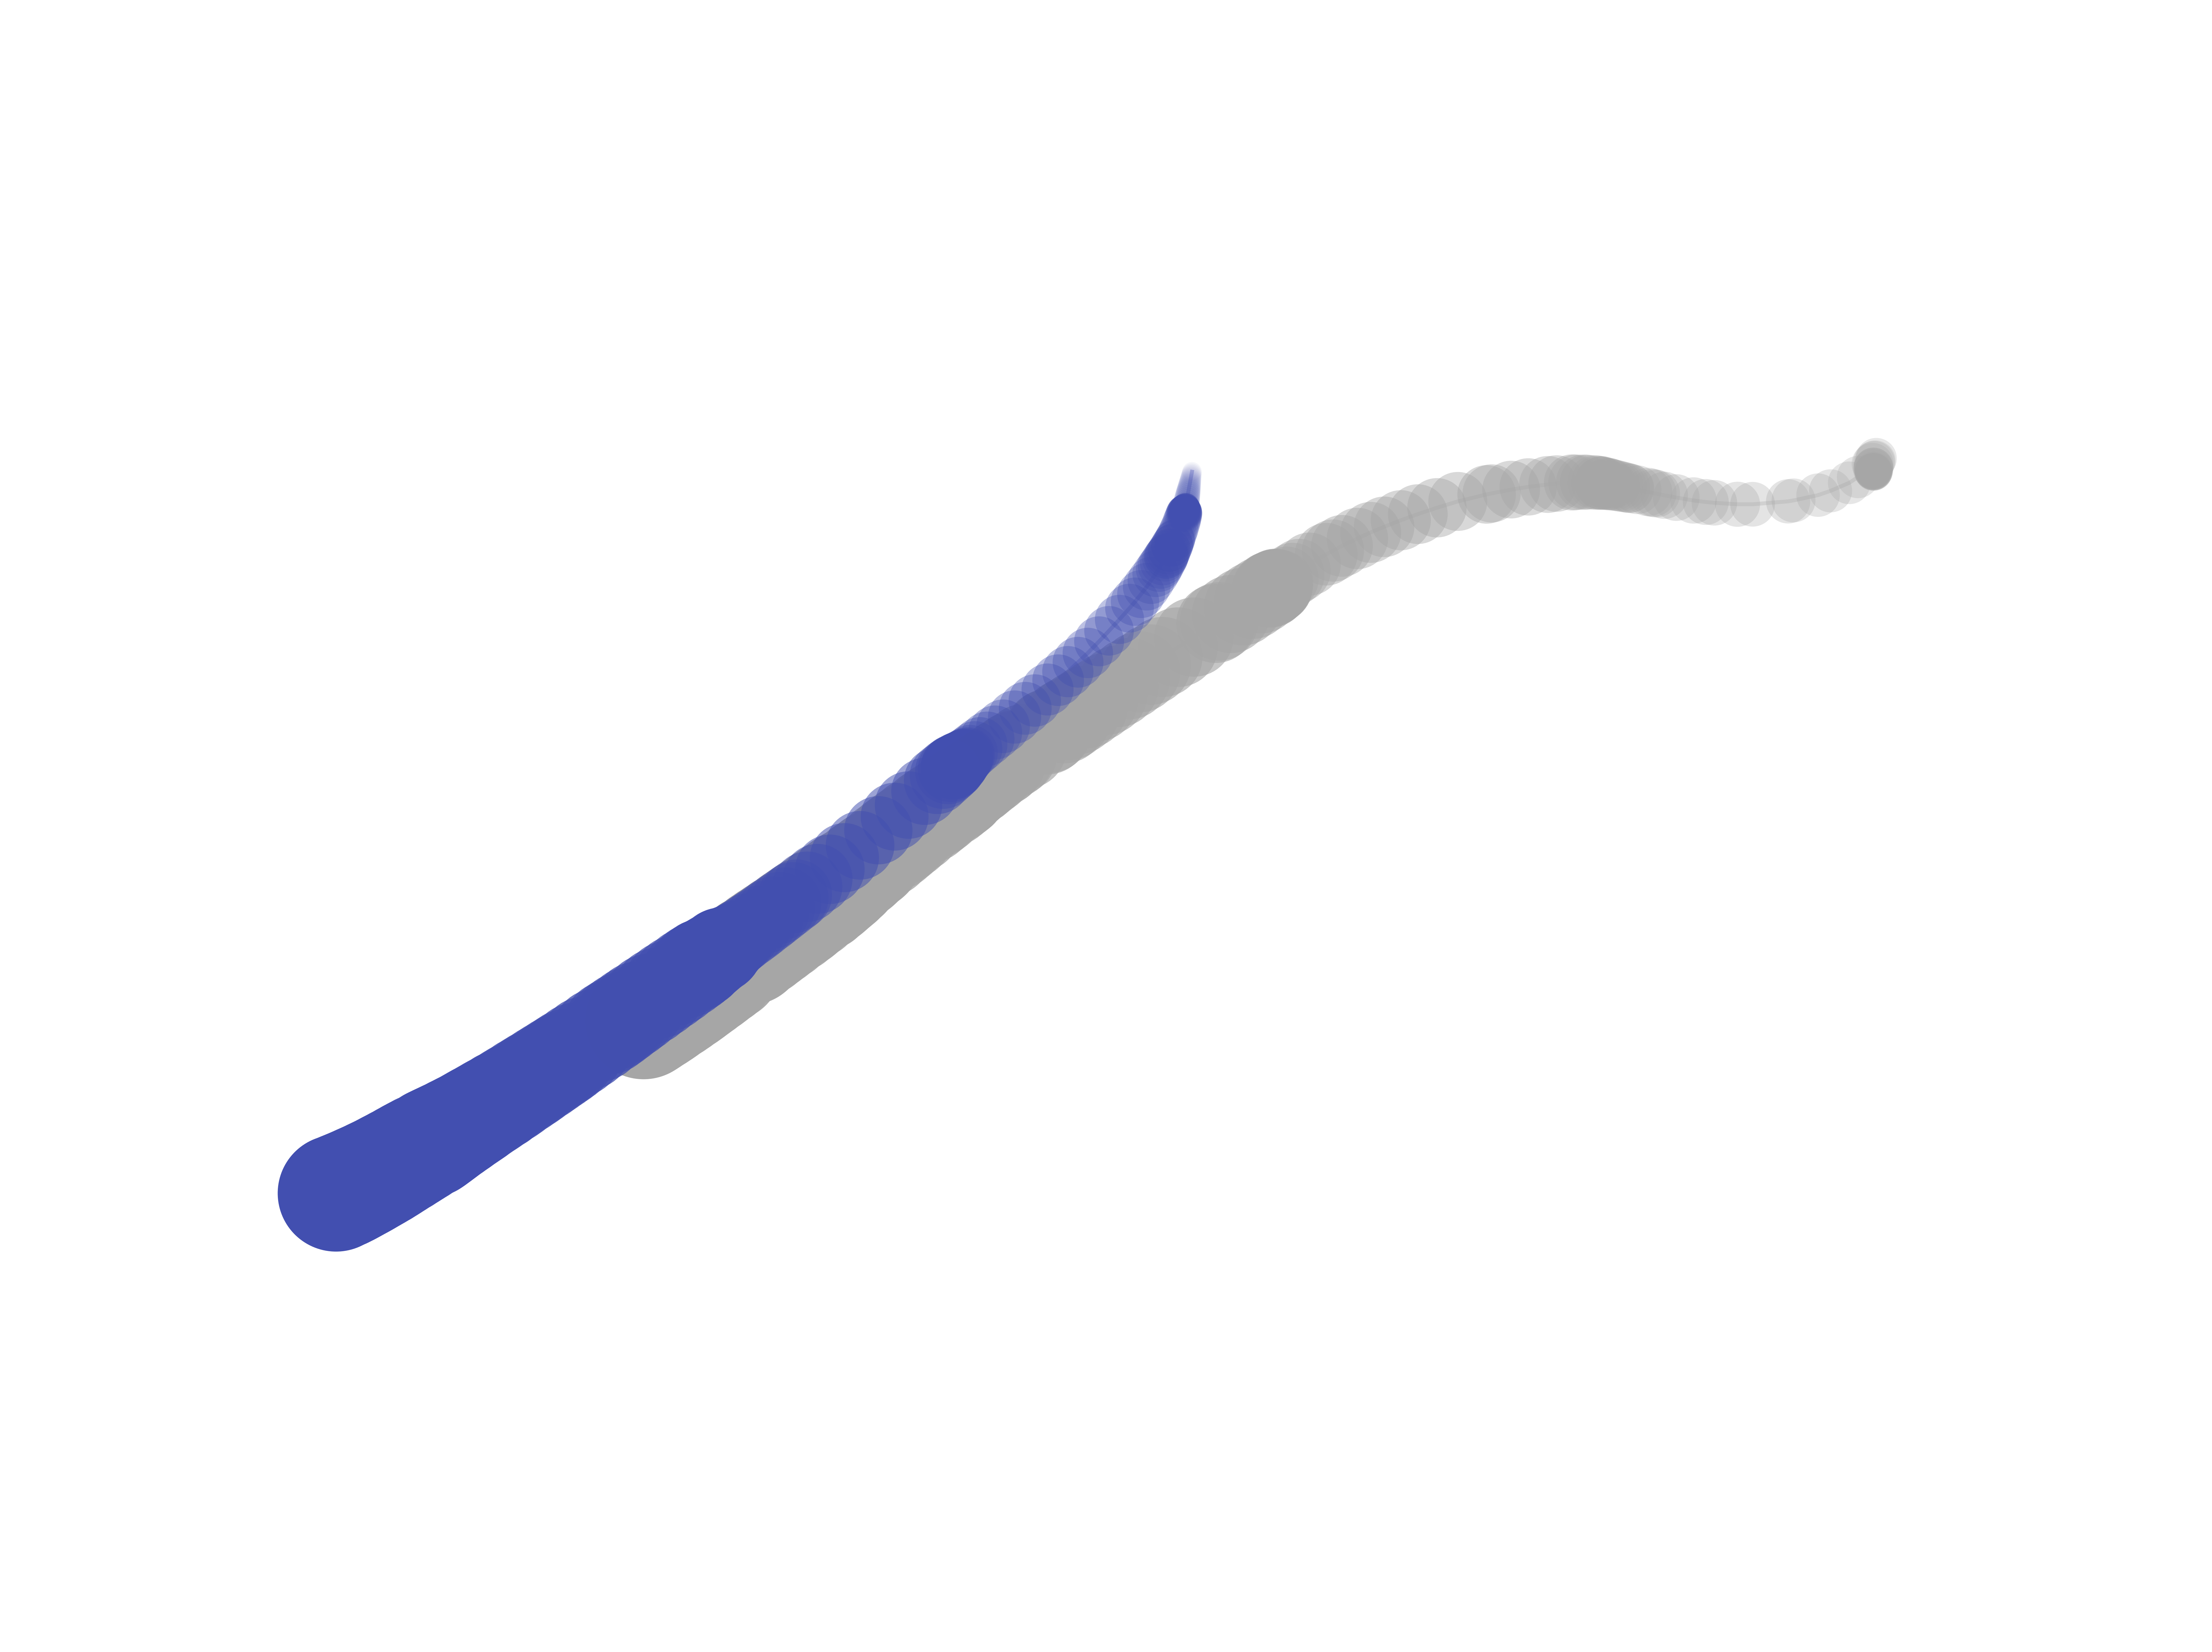

In [ ]:
BLUE = (0.26, 0.31, 0.69)
GREY = (0.65, 0.65, 0.65)
n_frames = len(x_force) 

df = load_all_summary()

video_id = 1051  
x1, y1, x2, y2, label = get_trajectory_by_id(df, video_id, downsample=1)

plot_trajectory_pair(
    x1[:n_frames], y1[:n_frames], x2[:n_frames], y2[:n_frames],
    color_a=GREY,
    color_b=BLUE,
    save_path=f"./traj_{video_id}_grey-blue.svg"
)